# Функции

In [1]:
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import EoN
from tqdm import trange
import pandas as pd
import shutil
import random
from sklearn.model_selection import train_test_split


import glob
import os
import math


from pathlib import Path

DATA_ROOT = Path('data')
SIM_ROOT = DATA_ROOT / 'simulations'
META_DIR = DATA_ROOT / 'meta'
SPLITS_ROOT = DATA_ROOT / 'splits'
RUNS_CSV = META_DIR / 'runs.csv'
for _d in (SIM_ROOT, META_DIR, SPLITS_ROOT / 'train', SPLITS_ROOT / 'val', SPLITS_ROOT / 'test'):
    _d.mkdir(parents=True, exist_ok=True)


In [2]:
def SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam, t_stream=20):
    """SEIR на графе с внешним импортом: каждый день число новых E ~ Poisson(lam) среди узлов,
    которые в начале дня были восприимчивы (S). Сетевые переходы считаются по тем же состояниям."""
    for node in G.nodes():
        G.nodes[node]['state'] = 0

    susceptible_count = []
    exposed_count = []
    infected_count = []
    recovered_count = []

    for day in range(tmax + 1):
        new_states = {}

        susceptible = sum(1 for n in G.nodes if G.nodes[n]['state'] == 0)
        exposed = sum(1 for n in G.nodes if G.nodes[n]['state'] == 1)
        infected = sum(1 for n in G.nodes if G.nodes[n]['state'] == 2)
        recovered = sum(1 for n in G.nodes if G.nodes[n]['state'] == 3)

        susceptible_count.append(susceptible)
        exposed_count.append(exposed)
        infected_count.append(infected)
        recovered_count.append(recovered)

        if day < t_stream:
            susceptibles = [n for n in G.nodes if G.nodes[n]['state'] == 0]
            k = np.random.poisson(lam)
            if k > 0 and susceptibles:
                k = min(int(k), len(susceptibles))
                for node in random.sample(susceptibles, k):
                    new_states[node] = 1

        for node in G.nodes():
            state = G.nodes[node]['state']
            if state == 2:
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor]['state'] == 0:
                        if random.random() < tau:
                            new_states[neighbor] = 1
                if random.random() < gamma:
                    new_states[node] = 3
            elif state == 1:
                if random.random() < alpha:
                    new_states[node] = 2

        for node, new_state in new_states.items():
            G.nodes[node]['state'] = new_state

    return [index for index in range(tmax + 1)], susceptible_count, exposed_count, infected_count, recovered_count


# Параметры

In [3]:
N = 10**4


tmax = 200
iterations = 50 # number of simulations
tau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate
#tau_boundaries = np.arange(0.01, 0.06, 0.002)
#tau_boundaries = [0.05]       # transmission rate
gamma = 0.08  # recovery rate
alpha = 0.1 # latent period rate
lam_boundaries = 2 ** np.arange(0, 7, 1)
t_stream = 20 # duration of import period (days)

# Расчёт на разных графах

## barabasi_albert_graph

In [4]:
G = nx.barabasi_albert_graph(N, 5)
GRAPH_KIND = 'barabasi_albert_graph'
graph_out = SIM_ROOT / GRAPH_KIND
if graph_out.exists():
    shutil.rmtree(graph_out)
graph_out.mkdir(parents=True, exist_ok=True)
if RUNS_CSV.exists():
    old_runs = pd.read_csv(RUNS_CSV)
    old_runs = old_runs[old_runs["graph_kind"] != GRAPH_KIND].reset_index(drop=True)
else:
    old_runs = pd.DataFrame()
for _lam in lam_boundaries:
    (graph_out / f'lam={int(_lam)}').mkdir(parents=True, exist_ok=True)
run_rows = []
seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        print('---')
        lam_dir = SIM_ROOT / GRAPH_KIND / f'lam={int(lam)}'
        lam_dir.mkdir(parents=True, exist_ok=True)
        for iter in range(0, iterations):
            t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam, t_stream=t_stream)

            S = np.array(S)
            E = np.array(E)
            I = np.array(I)
            R = np.array(R)

            beta_values = []
            num_days = len(t)
            for j in range(num_days - 1):
                if S[j] > 0 and I[j] > 0:
                    beta = - (S[j + 1] - S[j]) / (S[j] * I[j])
                else:
                    beta = np.nan
                beta_values.append(beta)
            beta_values.append(np.nan)
            df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
            output_file = f"seir_seed_{seed}.csv"
            out_path = lam_dir / output_file
            df_sim.to_csv(out_path, index=False)
            rel = (Path('simulations') / GRAPH_KIND / f'lam={int(lam)}' / output_file).as_posix()
            run_rows.append({
                "relative_path": rel,
                "graph_kind": GRAPH_KIND,
                "lam": float(lam),
                "tau": float(tau),
                "seed_in_graph": int(seed),
            })
            print(seed)
            seed += 1

new_df = pd.DataFrame(run_rows)
combined = pd.concat([old_runs, new_df], ignore_index=True).drop_duplicates(
    subset=["relative_path"], keep="last"
)
combined.to_csv(RUNS_CSV, index=False)
print('END')


---
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
---
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
---
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
---
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
---
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
---
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
27

## watts_strogatz_graph

In [5]:
G = nx.watts_strogatz_graph(N, 8, 0.1)
GRAPH_KIND = 'watts_strogatz_graph'
graph_out = SIM_ROOT / GRAPH_KIND
if graph_out.exists():
    shutil.rmtree(graph_out)
graph_out.mkdir(parents=True, exist_ok=True)
if RUNS_CSV.exists():
    old_runs = pd.read_csv(RUNS_CSV)
    old_runs = old_runs[old_runs["graph_kind"] != GRAPH_KIND].reset_index(drop=True)
else:
    old_runs = pd.DataFrame()
for _lam in lam_boundaries:
    (graph_out / f'lam={int(_lam)}').mkdir(parents=True, exist_ok=True)
run_rows = []
seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        print('---')
        lam_dir = SIM_ROOT / GRAPH_KIND / f'lam={int(lam)}'
        lam_dir.mkdir(parents=True, exist_ok=True)
        for iter in range(0, iterations):
            t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam, t_stream=t_stream)

            S = np.array(S)
            E = np.array(E)
            I = np.array(I)
            R = np.array(R)

            beta_values = []
            num_days = len(t)
            for j in range(num_days - 1):
                if S[j] > 0 and I[j] > 0:
                    beta = - (S[j + 1] - S[j]) / (S[j] * I[j])
                else:
                    beta = np.nan
                beta_values.append(beta)
            beta_values.append(np.nan)
            df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
            output_file = f"seir_seed_{seed}.csv"
            out_path = lam_dir / output_file
            df_sim.to_csv(out_path, index=False)
            rel = (Path('simulations') / GRAPH_KIND / f'lam={int(lam)}' / output_file).as_posix()
            run_rows.append({
                "relative_path": rel,
                "graph_kind": GRAPH_KIND,
                "lam": float(lam),
                "tau": float(tau),
                "seed_in_graph": int(seed),
            })
            print(seed)
            seed += 1

new_df = pd.DataFrame(run_rows)
combined = pd.concat([old_runs, new_df], ignore_index=True).drop_duplicates(
    subset=["relative_path"], keep="last"
)
combined.to_csv(RUNS_CSV, index=False)
print('END')


---
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
---
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
---
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
---
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
---
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
---
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
27

# Визуализация результатов

## Разделение по лямбде

### barabasi-albert graph

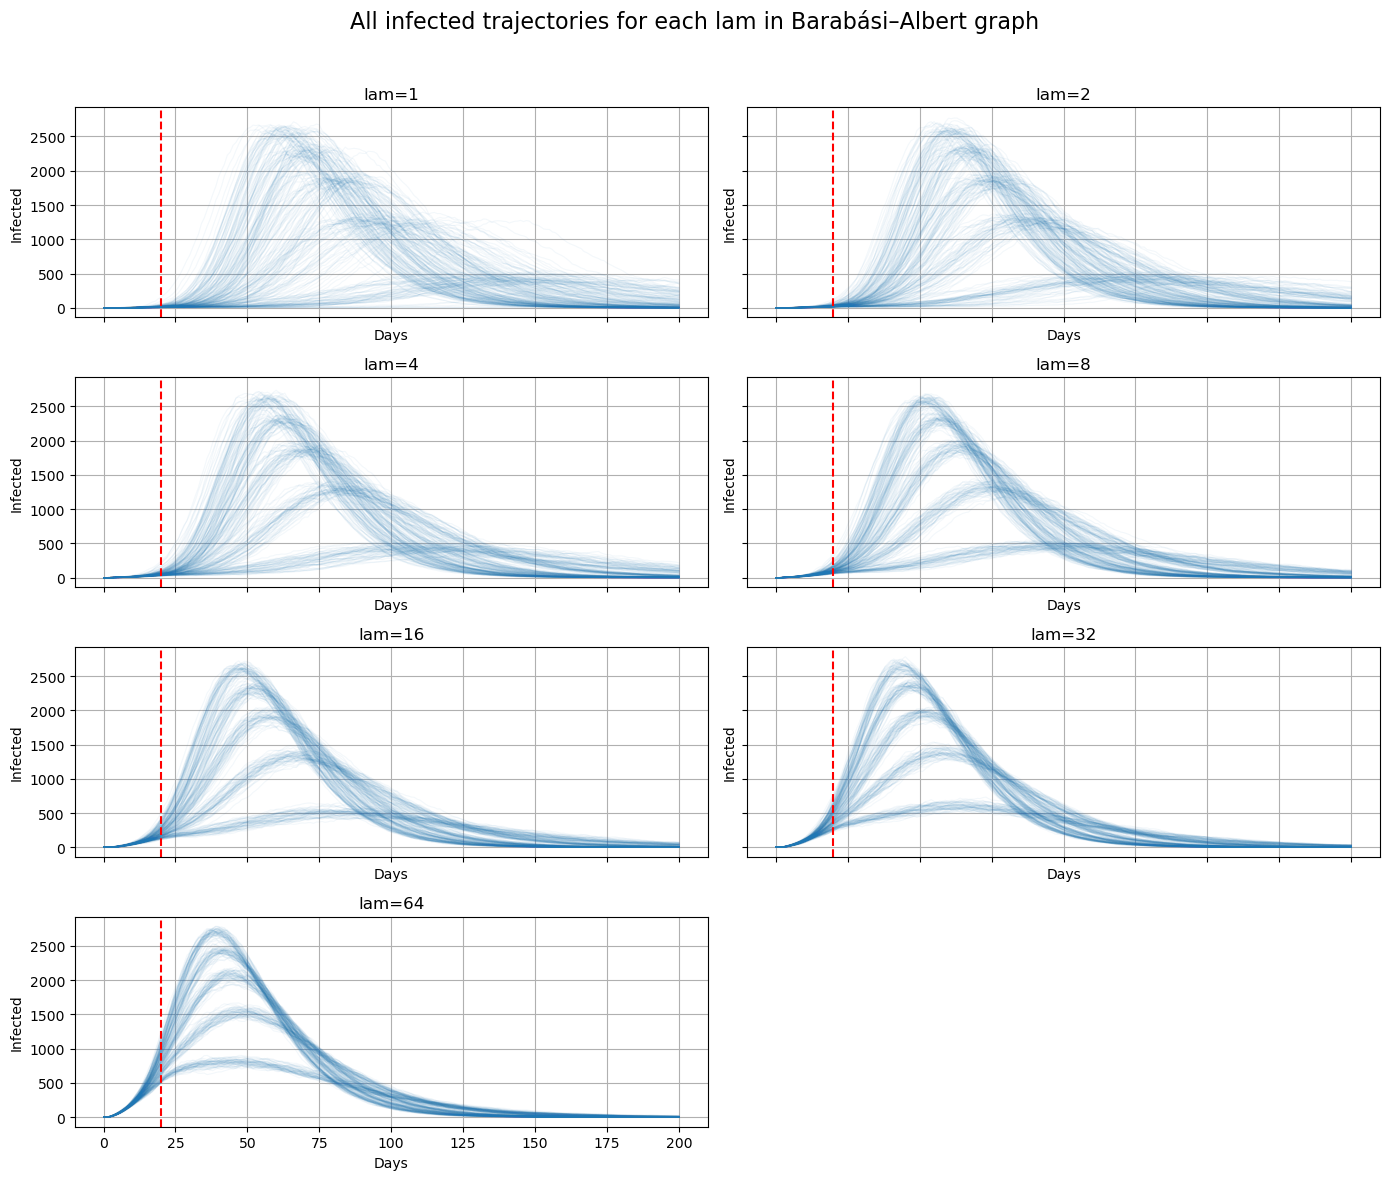

In [4]:
base_dir = str(SIM_ROOT / 'barabasi_albert_graph')
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.axvline(x=t_stream, color='red', linestyle='--', label='End of import period')
    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Barabási–Albert graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


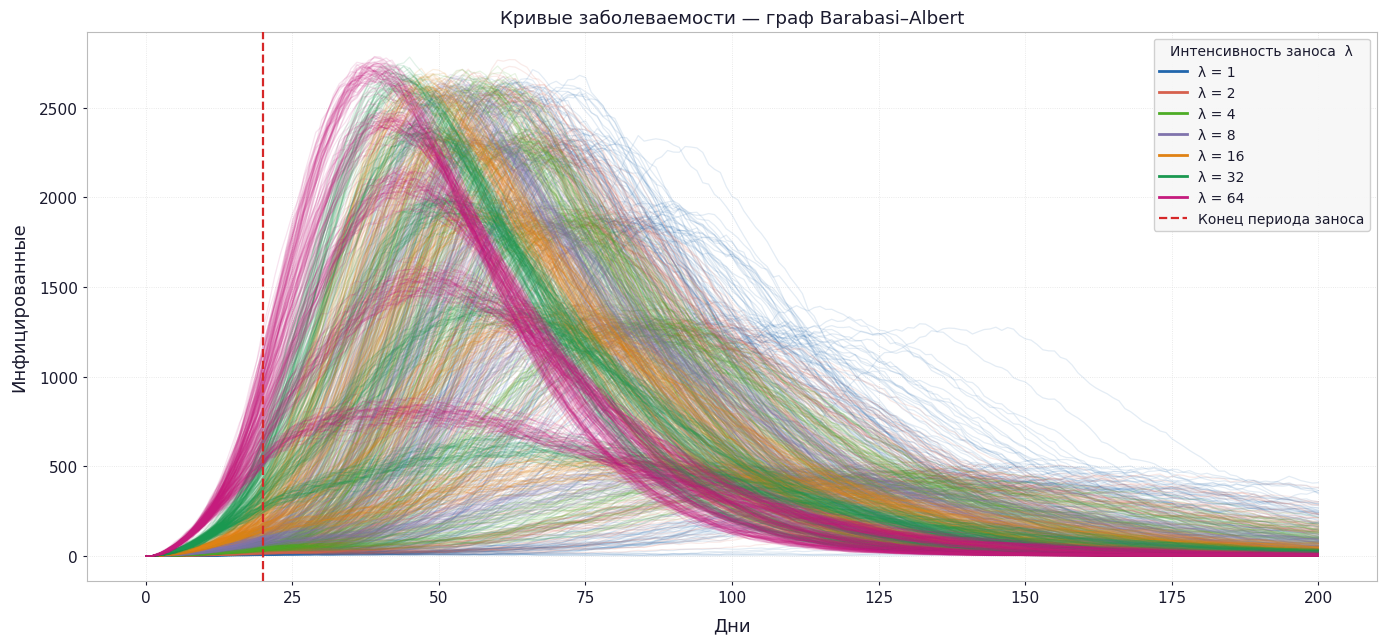

In [11]:
import matplotlib.lines as mlines
base_dir = str(SIM_ROOT / 'barabasi_albert_graph')
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

import matplotlib.lines as mlines

# ── Palette ───────────────────────────────────────────────────────────────────
COLORS = [
    '#2166AC', '#D6604D', '#4DAC26', '#8073AC',
    '#E08214', '#1A9850', '#C51B7D', '#4D4D4D',
    '#B2ABD2', '#FDB863',
]
BG     = '#FFFFFF'
GRID_C = '#DDDDDD'
TEXT_C = '#1A1A2E'
ACCENT = '#D62728'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.edgecolor':   '#BBBBBB',
    'axes.labelcolor':  TEXT_C,
    'xtick.color':      TEXT_C,
    'ytick.color':      TEXT_C,
    'text.color':       TEXT_C,
    'grid.color':       GRID_C,
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG)

legend_handles = []

for idx, lam_dir in enumerate(lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    color     = COLORS[idx % len(COLORS)]
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        continue

    first = True
    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(
            df['I'].to_numpy(),
            alpha=0.12,
            color=color,
            linewidth=0.9,
            label=f'λ = {lam_value}' if first else '_nolegend_',
        )
        if first:
            legend_handles.append(
                mlines.Line2D([], [], color=color, linewidth=2, label=f'λ = {lam_value}')
            )
            first = False

ax.axvline(x=t_stream, color=ACCENT, linestyle='--', linewidth=1.6,
           zorder=5)
legend_handles.append(
    mlines.Line2D([], [], color=ACCENT, linewidth=1.6,
                  linestyle='--', label='Конец периода заноса')
)

ax.set_xlabel('Дни', fontsize=13, labelpad=8)
ax.set_ylabel('Инфицированные', fontsize=13, labelpad=8)
ax.grid(True, axis='both', linestyle=':', alpha=0.8)
ax.tick_params(which='both', length=3)
for spine in ax.spines.values():
    spine.set_edgecolor('#BBBBBB')

legend = ax.legend(
    handles=legend_handles,
    framealpha=0.9,
    edgecolor='#CCCCCC',
    facecolor='#F7F7F7',
    fontsize=10,
    title='Интенсивность заноса  λ',
    title_fontsize=10,
    loc='upper right',
)
legend.get_title().set_color(TEXT_C)

#fig.suptitle(
#    'Кривые заболеваемости — граф Барабаши–Альберт',
#    fontsize=16, fontweight='bold', y=0.97, color=TEXT_C,
#)
#ax.set_title(
#    'Каждая кривая — одна симуляция; цвет соответствует интенсивности заноса λ',
#    fontsize=10, color='#666666', pad=6,
#)

ax.set_title(
    'Кривые заболеваемости — граф Barabasi–Albert',
    #fontsize=10, color='#666666', pad=6,
)



fig.tight_layout(rect=[0, 0, 1, 0.94])
#plt.savefig('ba_trajectories.png', dpi=180, bbox_inches='tight',
#            facecolor=BG, edgecolor='none')
plt.show()

### watts_strogatz_graph

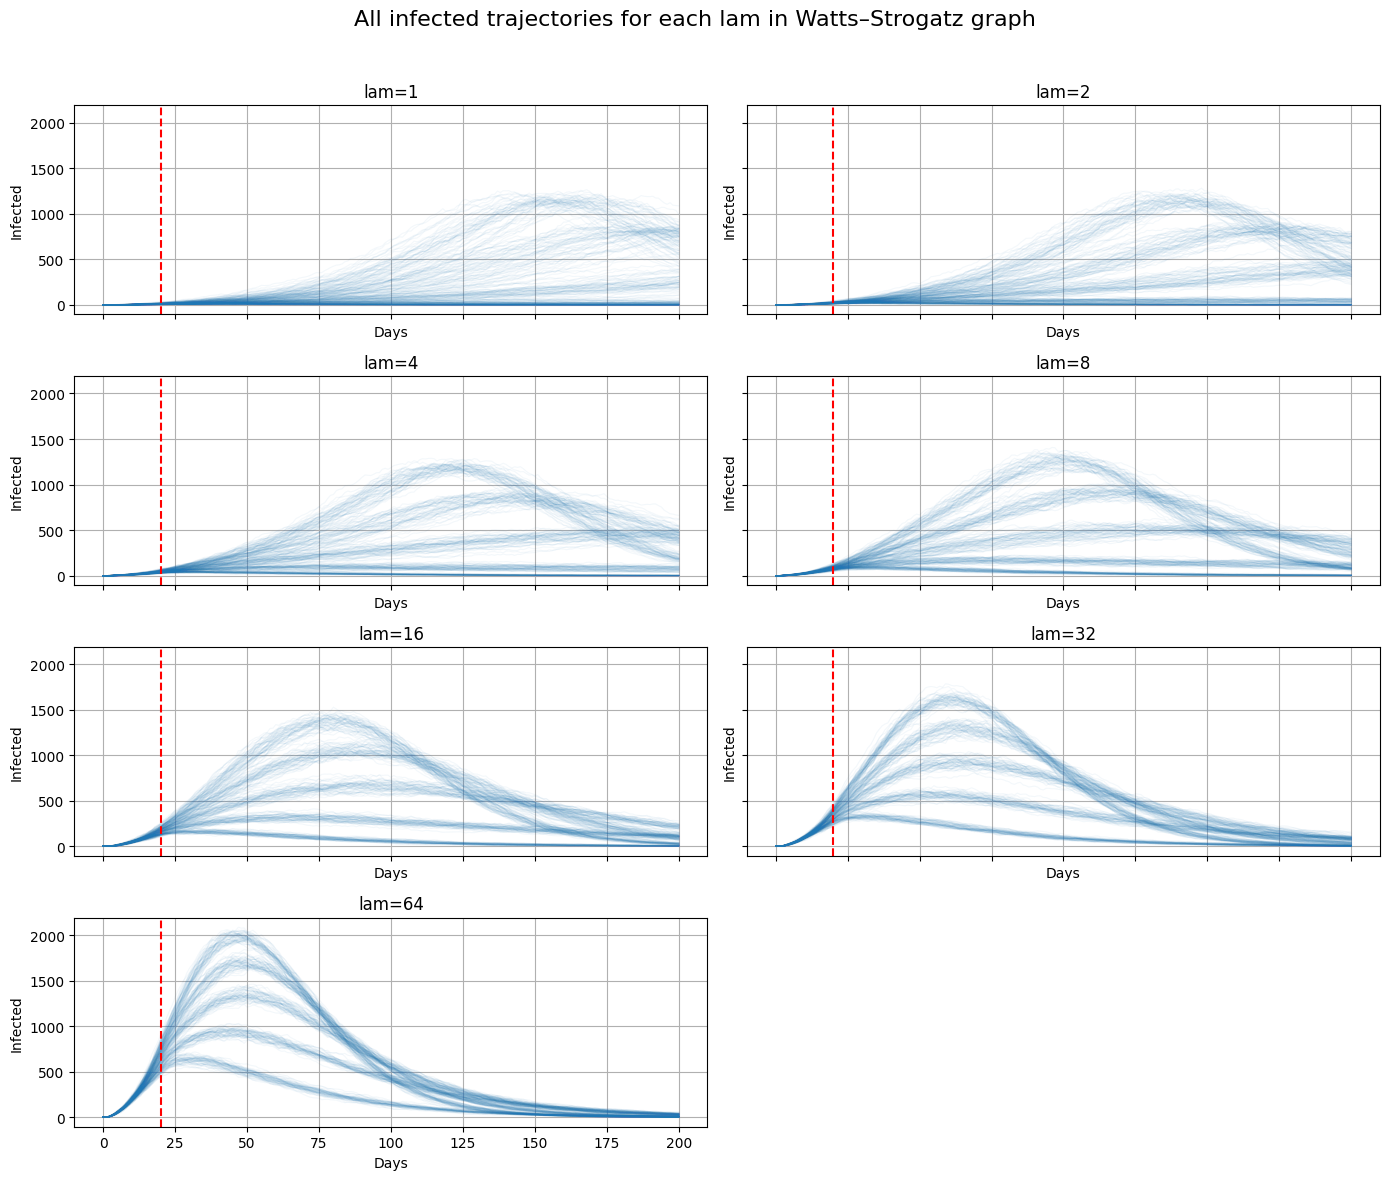

In [7]:
base_dir = str(SIM_ROOT / 'watts_strogatz_graph')
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.axvline(x=t_stream, color='red', linestyle='--', label='End of import period') 
    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Watts–Strogatz graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Анализ влияния степеней вершин

## Функция

In [19]:
import networkx as nx
import numpy as np
import random
from collections import defaultdict

def SEIR_network_with_poisson(G, tau, alpha, gamma, tmax, lam, t_stream=20, 
                              return_infection_counts=False, track_by_node=True):
    """
    SEIR на графе с внешним импортом + подсчёт количества заражений каждым узлом.
    
    Параметры:
        return_infection_counts: если True — возвращает список/массив количества заражений
        track_by_node: если True — сохраняет счётчик в атрибуты узлов (удобно для дальнейшего анализа)
    
    Возвращает:
        t, S, E, I, R, infection_counts
        где infection_counts — список длины |V| с количеством соседей, которых заразил каждый узел.
    """
    # Инициализация состояний
    for node in G.nodes():
        G.nodes[node]['state'] = 0
        if track_by_node:
            G.nodes[node]['infections_caused'] = 0

    susceptible_count = []
    exposed_count = []
    infected_count = []
    recovered_count = []

    for day in range(tmax + 1):
        new_states = {}

        # Подсчёт текущих состояний
        susceptible = sum(1 for n in G.nodes if G.nodes[n]['state'] == 0)
        exposed = sum(1 for n in G.nodes if G.nodes[n]['state'] == 1)
        infected = sum(1 for n in G.nodes if G.nodes[n]['state'] == 2)
        recovered = sum(1 for n in G.nodes if G.nodes[n]['state'] == 3)

        susceptible_count.append(susceptible)
        exposed_count.append(exposed)
        infected_count.append(infected)
        recovered_count.append(recovered)

        # Poisson импорт новых Exposed
        if day < t_stream:
            susceptibles = [n for n in G.nodes if G.nodes[n]['state'] == 0]
            k = np.random.poisson(lam)
            if k > 0 and susceptibles:
                k = min(int(k), len(susceptibles))
                for node in random.sample(susceptibles, k):
                    new_states[node] = 1

        # Сетевые переходы + подсчёт заражений
        for node in list(G.nodes()):
            state = G.nodes[node]['state']
            
            if state == 2:
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor]['state'] == 0 and neighbor not in new_states:
                        if random.random() < tau:
                            new_states[neighbor] = 1
                            # считаем вторичное заражение
                            if track_by_node:
                                G.nodes[node]['infections_caused'] += 1
                

                if random.random() < gamma:
                    new_states[node] = 3
                    
            elif state == 1:
                if random.random() < alpha:
                    new_states[node] = 2

        for node, new_state in new_states.items():
            G.nodes[node]['state'] = new_state

    # Сбор статистики заражений
    infection_counts = []
    if track_by_node or return_infection_counts:
        infection_counts = [G.nodes[node].get('infections_caused', 0) 
                           for node in G.nodes()]

    return (list(range(tmax + 1)), 
            susceptible_count, 
            exposed_count, 
            infected_count, 
            recovered_count, 
            infection_counts)

## Параметры

In [20]:
N = 10**4


tmax = 200
iterations = 100 # number of simulations
#tau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate
tau_boundaries = [0.03]       # transmission rate
gamma = 0.08  # recovery rate
alpha = 0.1 # latent period rate
#lam_boundaries = 2 ** np.arange(0, 10, 1)
lam_boundaries = [4]
t_stream = 20 # duration of import period (days)

## Симуляции

C:\Users\annen\AppData\Local\Temp\ipykernel_33916\1677859469.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 1000x600 with 0 Axes>

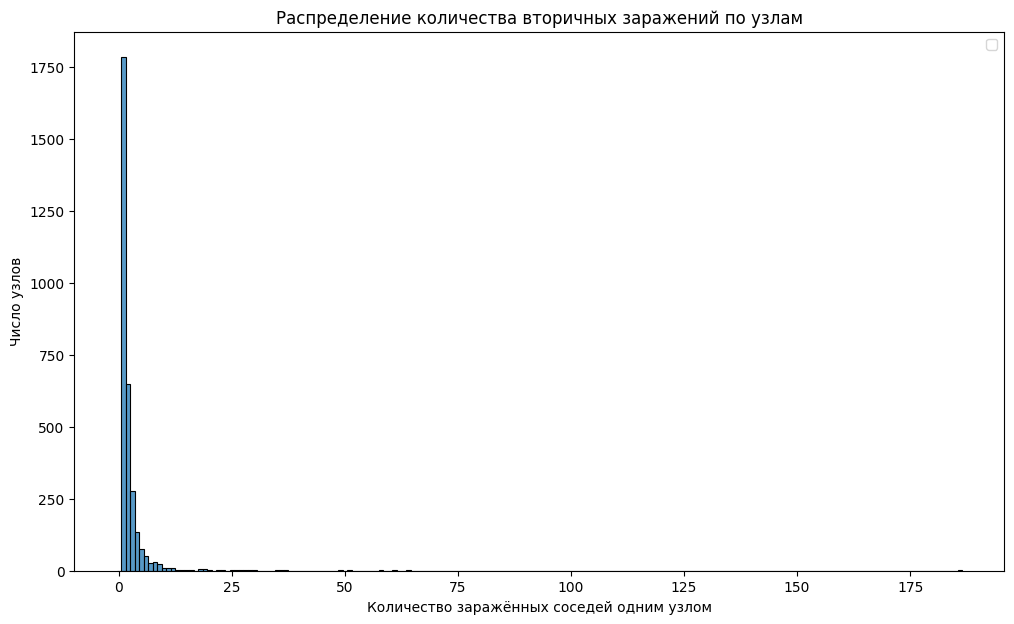

Узлов, заразивших хотя бы одного: 3129 из 10000
Максимальное число заражений одним узлом: 186


In [50]:
#G = nx.watts_strogatz_graph(N, 8, 0.1)
G = nx.barabasi_albert_graph(N, 5)

t, S, E, I, R, infection_counts = SEIR_network_with_poisson(
    G, tau=0.02, alpha=0.1, gamma=0.08, tmax=tmax, lam=8,
    t_stream=t_stream, return_infection_counts=True
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Гистограмма распределения вторичных заражений
plt.figure(figsize=(10, 6))
nonzero = np.array([x for x in infection_counts if x > 0])
max_inf = int(nonzero.max())

plt.figure(figsize=(12, 7))
ax = sns.histplot(
    nonzero,
    bins=np.arange(-0.5, max_inf + 1.5, 1),
    stat="count",
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.8
)
plt.title('Распределение количества вторичных заражений по узлам')
plt.xlabel('Количество заражённых соседей одним узлом')
plt.ylabel('Число узлов')
#plt.axvline(np.mean(nonzero), color='r', linestyle='--', label=f'Среднее = {np.mean(nonzero):.2f}')
plt.legend()
plt.show()

print(f"Узлов, заразивших хотя бы одного: {len(nonzero)} из {len(infection_counts)}")
print(f"Максимальное число заражений одним узлом: {max(infection_counts)}")

In [65]:
len(np.array(infection_counts)[np.array(infection_counts) >= 25])

17

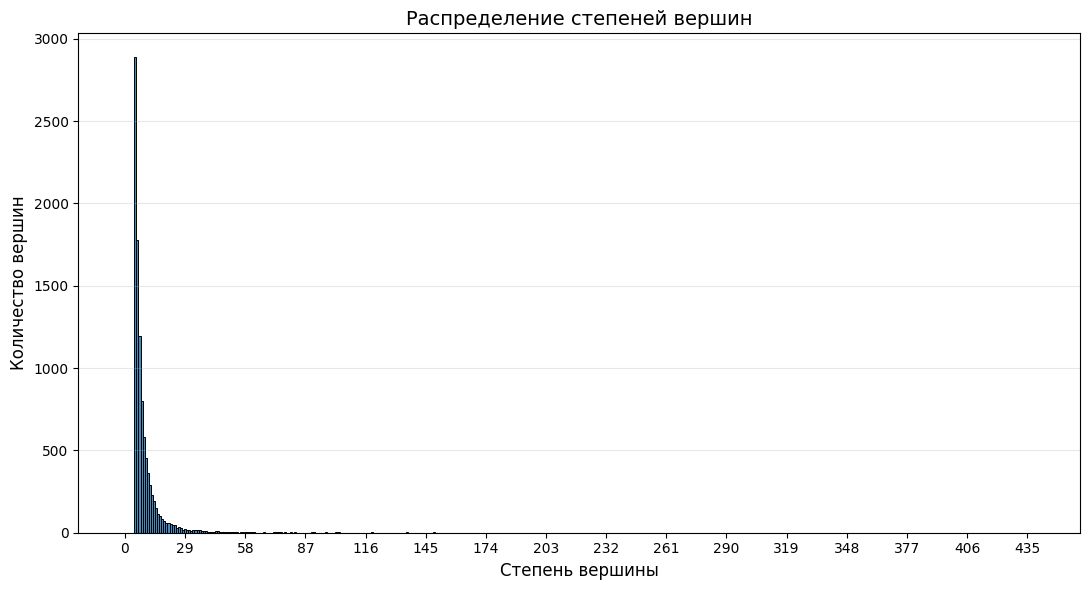

Статистика степеней:
Средняя:      9.995
Медиана:      7.0
Макс:         438
Мин:          5
Всего вершин: 10000


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

degrees = [G.degree(n) for n in G.nodes()]

plt.figure(figsize=(11, 6))

max_deg = max(degrees)

sns.histplot(
    degrees, 
    bins=np.arange(-0.5, max_deg + 1.5, 1),
    stat="count",
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

plt.title('Распределение степеней вершин', fontsize=14)
plt.xlabel('Степень вершины', fontsize=12)
plt.ylabel('Количество вершин', fontsize=12)

plt.grid(axis='y', alpha=0.3)

# Если максимальная степень большая — разрежаем метки
if max_deg > 40:
    plt.xticks(range(0, max_deg+1, max(5, max_deg//15)))

plt.tight_layout()
plt.show()

# Статистика
print("Статистика степеней:")
print(f"Средняя:      {np.mean(degrees):.3f}")
print(f"Медиана:      {np.median(degrees):.1f}")
print(f"Макс:         {max(degrees)}")
print(f"Мин:          {min(degrees)}")
print(f"Всего вершин: {len(degrees)}")

In [56]:
len(np.array(degrees)[np.array(degrees) >= 50])

129

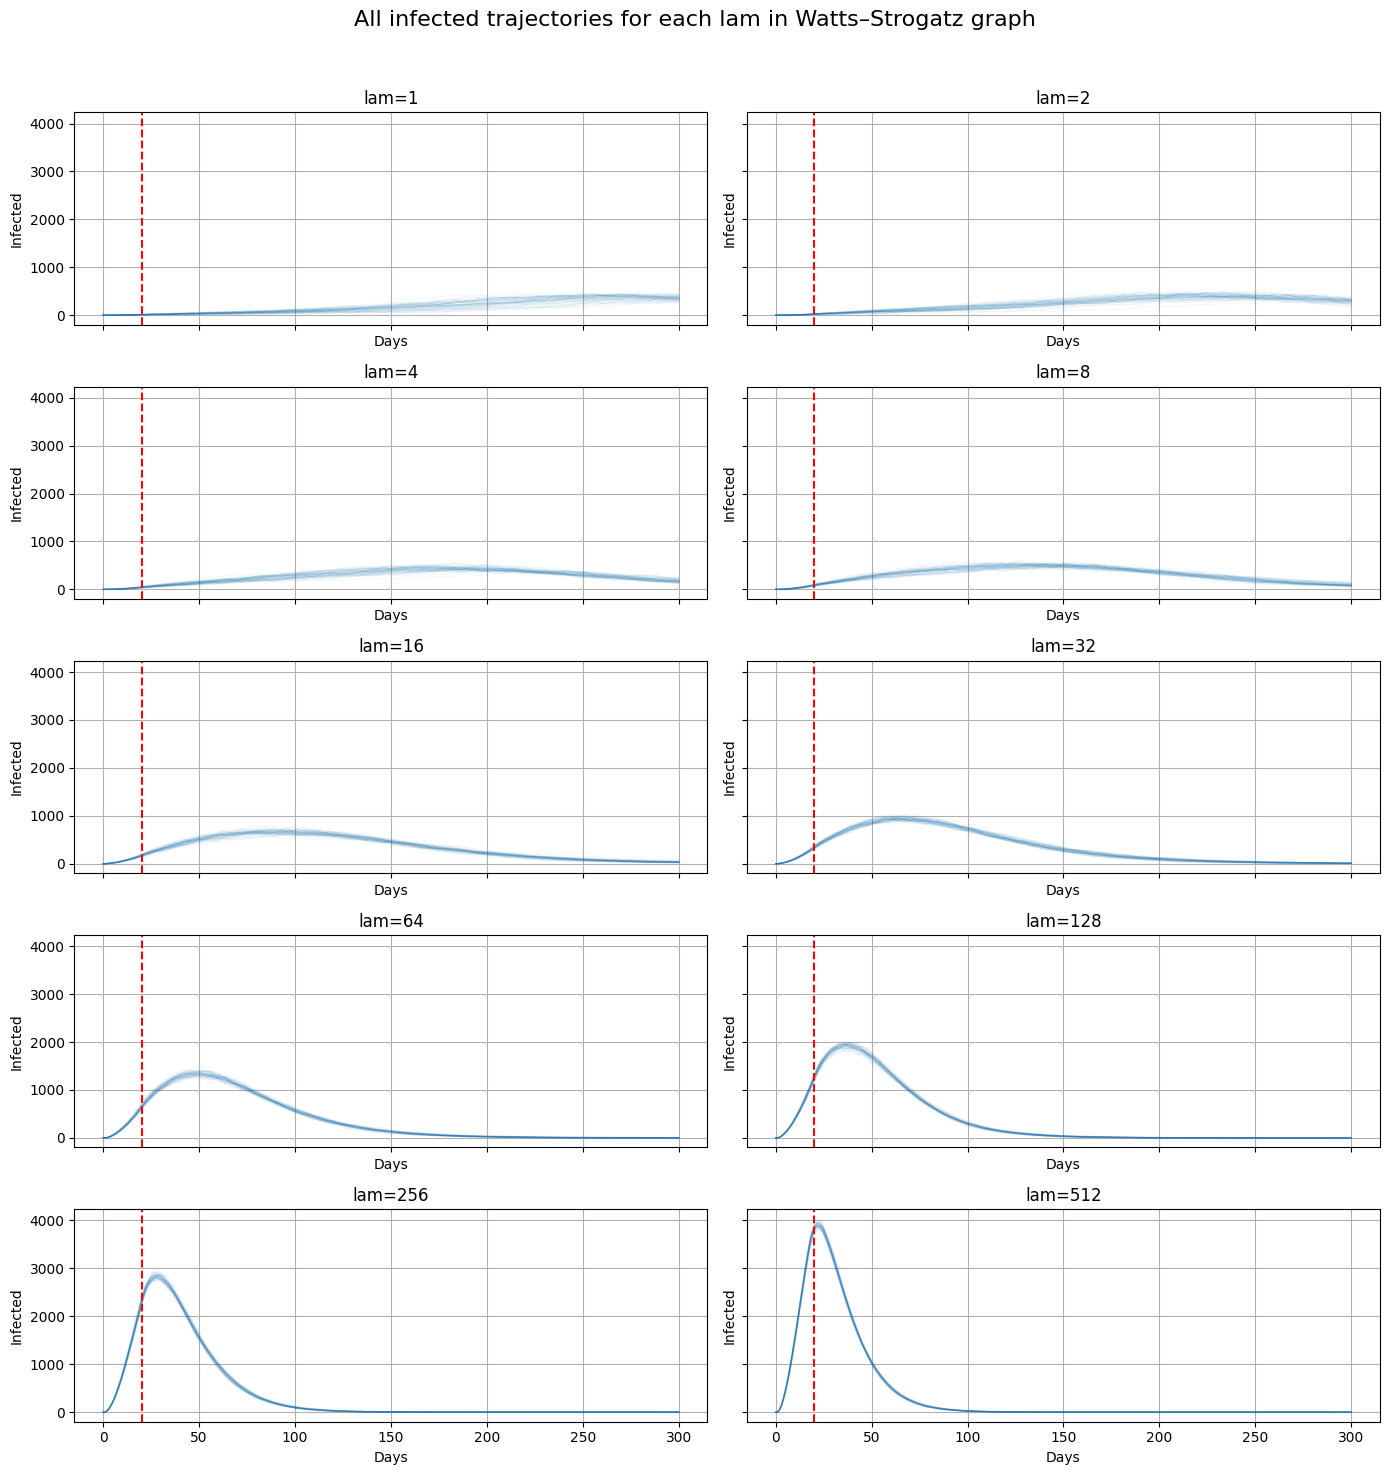

In [42]:
base_dir = str(SIM_ROOT / 'watts_strogatz_graph')
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.axvline(x=t_stream, color='red', linestyle='--', label='End of import period') 
    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Watts–Strogatz graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
